# import Datasets

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
df = pd.read_csv("Datasets/thyroid_dataset.csv")
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [12]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

# Standardize data

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_Scaler = scaler.fit_transform(X)

# Train Model Isolation Forest

In [16]:
from sklearn.ensemble import IsolationForest

In [22]:
iso = IsolationForest(
    n_estimators=200,# is ensemble model so it use multiple model so it no of model DT use in that
    contamination="auto" # it is how much outliers present in percentate if we give a percentage so
    # it detect accordingly if set auto so it use a default
)

In [23]:
label = iso.fit_predict(X_Scaler)

In [26]:
label  # -1 is outliers , 1 is normal data represent

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [27]:
print("no of outliers is", np.sum(label == -1))

no of outliers is 288


In [28]:
print("no of normal pt is", np.sum(label == 1))

no of normal pt is 6628


# visualization of LOF

## pca for dataset conver into 2 feature

In [29]:
from sklearn.decomposition import PCA

In [30]:
pca = PCA(n_components=2)

In [31]:
X_pca = pca.fit_transform(X_Scaler)

<Axes: >

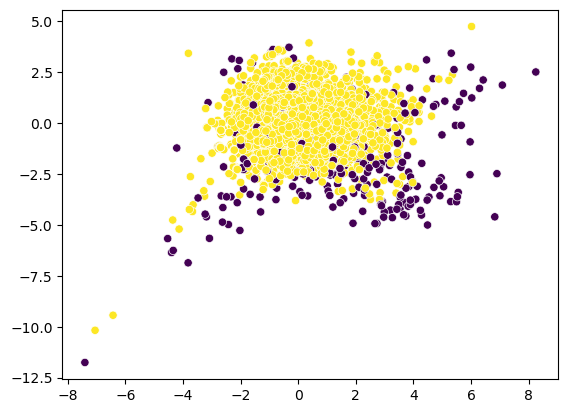

In [33]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],c=label)

# Local Outliers Factor for Anomaly Detection

In [34]:
from sklearn.neighbors import LocalOutlierFactor

In [53]:
lof = LocalOutlierFactor(
    contamination= 0.0361  # percentage of datasets outliers present not compulsary factor
 )

In [54]:
label = lof.fit_predict(X_Scaler)

In [55]:
print("no of outliers is", np.sum(label == -1))

no of outliers is 250


# visualization

<Axes: >

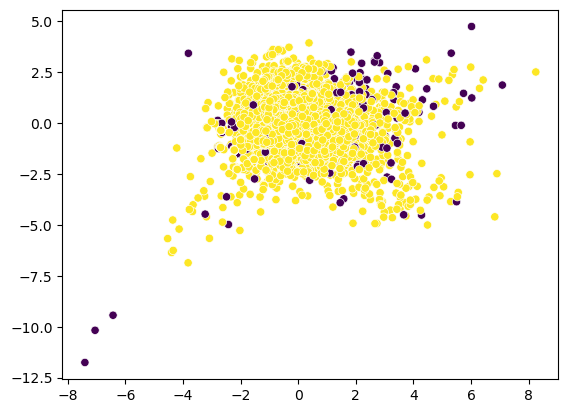

In [56]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],c=label)